In [22]:
"""
https://www.tdk-electronics.tdk.com/inf/80/db/fer/pq_40_40.pdf
https://www.tdk-electronics.tdk.com/inf/80/db/fer/pq_26_25.pdf
https://www.tdk-electronics.tdk.com/inf/80/db/fer/pq_20_20.pdf
"""
import pandas as pd
import matplotlib.pyplot as plt
import os
import logging
import numpy as np

from hybridmag.utils import comsol_interface as comsol
from meta import paths
from meta.plot_settings import colors

# -------------------------
# Logging
# -------------------------
logging.basicConfig(format='%(levelname)s:%(message)s', level=logging.INFO)

# -------------------------
# Matplotlib settings
# -------------------------
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.sans-serif": ["Bitstream Vera Sans", "DejaVu Sans", "Helvetica", "Arial", "sans-serif"],
    "font.size": 10.0,
    "text.latex.preamble": r"\usepackage{upgreek}\usepackage{siunitx}",
    "mathtext.fontset": "custom",
    "mathtext.rm": "Bitstream Vera Serif",
    "mathtext.it": "Bitstream Vera Serif:italic",
    "mathtext.bf": "Bitstream Vera Serif:bold"
})

# -------------------------
# Colors (consistent per curve type)
# -------------------------
color_fem = "tab:blue"
color_meas = "tab:red"

cm = 1 / 2.54
# link2measurements = os.path.join(paths.measurements, "2025_08_18/")
link2measurements = paths.measurement_data.joinpath("2025_12_23")


cut_names = [["B6_I_1", "B6_II_1"],
              ["M8_I_1", "M8_II_1"],
              ["Z2_I_1", "Z2_Y0_I_1"]]
cut_labels = [["set 1", "set 2"],
               ["set 1", "set 2"],
               ["set 1", "set 2"]]


# cut_names = [["B6_I_1", "B6_I_2", "B6_I_3"],
#               ["M8_I_1", "M8_I_2", "M8_I_3"],
#               ["Z2_I_1", "Z2_I_2", "Z2_I_3"]]
# cut_labels = [["set 1", "set 2", "set 3"],
#                ["set 1", "set 2", "set 3"],
#                ["set 1", "set 2", "set 3"]]

In [23]:
core_names = ["PQ2020", "PQ2625", "PQ4040"]
core_names_for_plot = ["PQ20/20", "PQ26/25", "PQ40/40"]
core_volumes = [2850 / 1e9, 6540 / 1e9, 17580 / 1e9]


# FEM
df_Pv = comsol.read_df_from_comsol_table(
    link2file=f"N:/groups/lea/data/Employees/tpiepe/Simulationen/TPEL26/simulations/PQ_model/FEM_vs_measurement/core_losses.txt",
    header=["f"] + core_names
)
df_Pv_static = comsol.read_df_from_comsol_table(
    link2file=f"N:/groups/lea/data/Employees/tpiepe/Simulationen/TPEL26/simulations/PQ_model/FEM_vs_measurement/core_losses_static.txt",
    header=["f"] + core_names
)

PQ2020
Average deviation FEM         : -31.2 %
Average deviation FEM (static): -40.7 %
PQ2625
Average deviation FEM         : -24.7 %
Average deviation FEM (static): -44.3 %
PQ4040
Average deviation FEM         : -19.7 %
Average deviation FEM (static): -46.7 %


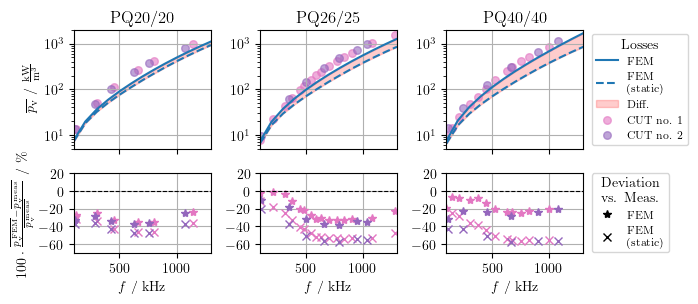

In [26]:
# -------------------------
# Create subplots: 2 rows (losses, deviation), N cols (cores)
# -------------------------
fig, axes = plt.subplots(
    2, len(core_names),
    figsize=(18 * cm, 8 * cm),
    sharex=True,
    gridspec_kw={'height_ratios': [1.5, 1]},  # top taller than bottom
)

# Collect all frequencies for x-axis range
all_freqs = []


for col, (core_name, core_volume) in enumerate(zip(core_names, core_volumes)):
    ax_loss = axes[0, col]
    ax_dev = axes[1, col]

    # FEM
    p_fem = df_Pv[core_name] / core_volume / 1000
    f_fem = df_Pv["f"] / 1000
    ax_loss.semilogy(f_fem, p_fem, label="FEM", color=color_fem)
    all_freqs.extend(df_Pv["f"].values)

    # FEM static
    p_fem_static = df_Pv_static[core_name] / core_volume / 1000
    f_fem_static = df_Pv_static["f"] / 1000
    ax_loss.semilogy(f_fem_static, p_fem_static, "--", label="FEM\n(static)", color=color_fem)
    all_freqs.extend(df_Pv_static["f"].values)

    # Highlight difference in loss plot
    ax_loss.fill_between(
        f_fem,
        p_fem,
        p_fem_static,
        color="red",
        alpha=0.2,
        label="Diff."
    )

    # Measurement (of different cores)
    # Initialize lists to store all measurement data
    f_meas_all = []
    p_meas_all = []
    cut_labels_all = []
    for i_cut, cut_name in enumerate(cut_names[col]):
        df = pd.read_csv(link2measurements.joinpath(f"{core_name}/{cut_name}.csv"))

        # Filter to avoid extrapolation
        df = df.loc[df["f"].to_numpy() < max(f_fem)*1000]
        # df = df.loc[df["f"].to_numpy() < 1.2e6]
        df = df.sort_values(by='f')
        f_meas = df['f'] / 1000
        p_meas = df['p_density_hyst'] / 1000
        ax_loss.scatter(f_meas, p_meas, s=30, alpha=0.6, label=f"CUT no. {i_cut + 1}", color=colors[i_cut])
        f_meas_all.extend(f_meas)
        p_meas_all.extend(p_meas)
        cut_labels_all.extend([cut_name] * len(f_meas))  # tag each point
        all_freqs.extend(df["f"].values)

        # -------------------------
        # Deviation calculation
        # -------------------------
        # f_rec = np.linspace(100, 1300, 20)  # in kHz
        # p_meas_interp = fit_meas(f_rec)
        # p_fem_interp = fit_FEM(f_rec)
        # p_fem_static_interp = fit_FEM_static(f_rec)

        # Interpolate so both curves are evaluated on the same f-grid (f_meas already exists)
        p_fem_interp = np.interp(f_meas, f_fem, p_fem)
        p_fem_static_interp = np.interp(f_meas, f_fem_static, p_fem_static)

        dev_fem = (p_fem_interp - p_meas) / p_meas * 100
        dev_fem_static = (p_fem_static_interp - p_meas) / p_meas * 100

        ax_dev.plot(f_meas, dev_fem, "*", color=colors[i_cut])
        ax_dev.plot(f_meas, dev_fem_static, "x", color=colors[i_cut])
    ax_dev.axhline(0, color="black", linestyle="--", linewidth=0.8)
    ax_dev.set_ylim(-70, 20)
    ax_dev.set_yticks([-60, -40, -20, 0, 20])


    # Create DataFrame with cut info
    df_meas = pd.DataFrame({
        'f': f_meas_all,
        'p': p_meas_all,
        'cut_name': cut_labels_all
    })

    # Sort by frequency (f) in ascending order
    df_meas = df_meas.sort_values(by='f').reset_index(drop=True)
    f_meas = df_meas["f"]
    p_meas = df_meas["p"]

    # Interpolate so both curves are evaluated on the same f-grid (f_meas already exists)
    p_fem_interp = np.interp(f_meas, f_fem, p_fem)
    p_fem_static_interp = np.interp(f_meas, f_fem_static, p_fem_static)

    dev_fem = (p_fem_interp - p_meas) / p_meas * 100
    dev_fem_static = (p_fem_static_interp - p_meas) / p_meas * 100


    # Set y-axis limit after the loop
    ax_loss.set_ylim(5, 2000)

    # -------------------------
    # Fit results
    # -------------------------
    # Fit measurements
    coeffs_meas = np.polyfit(df_meas["f"], df_meas["p"], 3)
    fit_meas = np.poly1d(coeffs_meas)

    # Fit FEM
    coeffs_FEM = np.polyfit(f_fem, p_fem, 3)
    fit_FEM = np.poly1d(coeffs_FEM)

    # Fit FEM static
    coeffs_FEM_static = np.polyfit(f_fem_static, p_fem_static, 3)
    fit_FEM_static = np.poly1d(coeffs_FEM_static)



    # Manufacturer deviation
    # ax_dev.axhline(30, color="black", linestyle="--", linewidth=0.8)
    # ax_dev.axhline(-30, color="black", linestyle="--", linewidth=0.8)



    # -------------------------
    # Fitted values in the recommended frequency range
    # -------------------------
    # rec_p_meas_interp = fit_meas(f_meas)
    # rec_p_fem_interp = fit_FEM(f_meas)
    # rec_p_fem_static_interp = fit_FEM_static(f_meas)

    # ax_loss.semilogy(f_meas, rec_p_meas_interp, "x", color=colors[4])

    # -------------------------
    # Mean deviations (in the recommended frequency range)
    # -------------------------
    rec_dev_fem = (p_fem_interp - p_meas) / p_meas
    rec_dev_fem_static = (p_fem_static_interp - p_meas) / p_meas
    mean_dev_fem = np.mean(rec_dev_fem)
    mean_dev_fem_static = np.mean(rec_dev_fem_static)
    print(f"{core_name}")
    print(f"Average deviation FEM         : {np.round(100*mean_dev_fem, 1)} %")
    print(f"Average deviation FEM (static): {np.round(100*mean_dev_fem_static, 1)} %")

    # -------------------------
    # Highlight the difference
    # -------------------------
    # ax_dev.fill_between(
    #     f_meas,
    #     dev_fem,
    #     dev_fem_static,
    #     color="red",
    #     alpha=0.2,
    #     interpolate=True,
    #     label="Diff."
    # )

# -------------------------
# Labels, limits, legend
# -------------------------
# Row 1 (losses)
for ax in axes[0, :]:
    ax.set_xlabel("")
axes[0, 0].set_ylabel(r"$\overline{p_\mathrm{v}}$ / $\frac{\mathrm{kW}}{\mathrm{m}^3}$")

# Row 2 (deviation)
for ax in axes[1, :]:
    ax.set_xlabel(r"$f$ / kHz")
axes[1, 0].set_ylabel(r"$100 \cdot \frac{\overline{p_\mathrm{v}^\mathrm{\,FEM}}-\overline{p_\mathrm{v}^\mathrm{\,meas}}}{\overline{p_\mathrm{v}^\mathrm{\,meas}}}$ / $\qty{}{\percent}$")

# Shared x-axis range
fmin = min(all_freqs) / 1000
fmax = max(all_freqs) / 1000
for row in range(2):
    for col in range(len(core_names)):
        axes[row, col].set_xlim(fmin, fmax)
        axes[row, col].grid(True)

# -------------------------
# Titles
# -------------------------
for col, core_name in enumerate(core_names):
    axes[0, col].set_title(core_names_for_plot[col])


# -------------------------
# Legends
# -------------------------
# Losses legend
axes[0, -1].legend(
    loc="center left",          # position relative to the axes
    bbox_to_anchor=(1.02, 0.5), # slightly to the right
    fontsize=8,
    frameon=True,
    title="Losses"
)


# Deviation legend
# Placeholder for legend (should come first)
axes[1, -1].plot([], [], "*", label="FEM", color="k")
axes[1, -1].plot([], [], "x", label="FEM\n(static)", color="k")
axes[1, -1].legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=8,
    frameon=True,
    title="Deviation \n vs. Meas."
)

plt.tight_layout()

# -------------------------
# Save + show
# -------------------------
plt.savefig(paths.grafics.joinpath("losses_FEM_vs_measurement.pdf"))
plt.show()

In [25]:
# datasheet: max. loss densities of N49 at 50 mT, 500 kHz, and 100 °C
p_v_PQ4040 = 4.8 / 17580 / 1e-9
p_v_PQ2625 = 2.3 / 6540 / 1e-9
p_v_PQ2020 = 0.9 / 2850 / 1e-9

print(f"{p_v_PQ4040 = } W")
print(f"{p_v_PQ2625 = } W")
print(f"{p_v_PQ2020 = } W")

p_v_PQ4040 = 273037.542662116 W
p_v_PQ2625 = 351681.9571865443 W
p_v_PQ2020 = 315789.4736842105 W
